# Checking the emulator against the full model

_Never trust an emulator you haven't tested against the thing it replaces._


In ["DSI basics"](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) we trained a DSI emulator on the prior Monte Carlo ensemble, history-matched it against the synthetic truth in seconds, and read a posterior forecast off the emulator: the distribution of peak SO₄ at the supply well (`wellopt`) over the supply period (days 308–728), summarised as its median and P95. That whole exercise never touched the process model. The emulator stood in for it.

Before we lean on the emulator for dataworth ([part1_07](../part1_07_dataworth/dizon_dataworth.ipynb)) and optimization ([part1_08](../part1_08_optimization/dizon_optimization.ipynb)), we owe it one honest test. We already ran a *fidelity check* on the emulator's **prior** predictions — held-out realisations the emulator never saw, in part1_05. That tested whether DSI reproduces the prior. It did not test whether DSI's **posterior** — the result of conditioning the emulator on data — matches what the full reactive-transport model produces when *it* is history-matched against the same data, with the same noise, toward the same synthetic truth.

So here we do the expensive thing, once. We history-match the full DIZON model with PESTPP-IES — the same algorithm, the same observations, the same noise model, the same synthetic truth — and compare its posterior against the DSI posterior on the forecast. This is the notebook where the thesis of the whole series — *emulate, because full-model ensembles are unaffordable for reactive transport* — gets its receipt.

The validation runs only one direction, though, and it pays to be clear about it up front. The full-model history match is **not an oracle**. It is a second ensemble smoother fighting the same model nonlinearity, and (as we will see) it struggled to converge. We are not asking "does the emulator match the truth the full model found" — neither machine is handed the truth. We are asking whether two independent conditioning routes, given the same data, *bound the same answer*. Where they agree, the shortcut is vindicated. Where they disagree, we name it, attribute it, and decide which we trust — on the merits, not on majority vote.

This notebook **runs nothing**. The full-model history match was run for you and shipped, thinned, in [`prebaked/full_model_ies/`](../../prebaked/full_model_ies/). Every cell below loads or plots; no model, no PESTPP-IES. The compute bill it represents is stated plainly in the next section, because the size of that bill is the entire argument for emulation.

### Admin

We start with the usual imports and dependency checks. As in the rest of the series, the vendored `flopy` and `pyemu` are pulled from the repo's `dependencies/` tree — the asserts below fail loudly if a system install has shadowed them.


In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
sys.path.insert(0, "..")
import herebedragons as hbd

plt.rcParams['font.size'] = 10

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


**Prerequisite check.** This notebook consumes two products and loads both — it computes nothing from a model:

- the **prebaked full-model history match** in [`prebaked/full_model_ies/`](../../prebaked/full_model_ies/) — a thinned control file (`hm.pst`) and per-iteration observation ensembles (`hm.{0,1,2,3}.obs.jcb`). This is the expensive run, shipped so you do not repeat it; if it is missing, the regenerating script is `etc/run_full_model_ies.py`.
- the **DSI posterior** from ["DSI basics"](../part1_05_dsi_basics/dizon_dsi_basics.ipynb), written into that notebook's `dsi_template/` working directory. If it is missing, go run part1_05 first.

In [2]:
# the prebaked full-model history match (the expensive run, shipped thinned)
fm_d = Path(os.path.join("..", "..", "prebaked", "full_model_ies"))
hm_pst_path = fm_d / "hm.pst"
if not hm_pst_path.exists():
    raise Exception(
        "could not find the prebaked full-model history match at "
        f"'{hm_pst_path}'. It ships in the repo's prebaked/ tree; if you need to "
        "regenerate it from a master_hm run, see 'etc/run_full_model_ies.py'.")

# the DSI posterior, written into part1_05's working directory
dsi_d = Path(os.path.join("..", "part1_05_dsi_basics", "dsi_template"))
if not (dsi_d / "dsi.pst").exists():
    raise Exception(
        "could not find the DSI posterior at "
        f"'{dsi_d / 'dsi.pst'}'. Run the "
        "'../part1_05_dsi_basics/dizon_dsi_basics.ipynb' notebook first.")

print(f"full-model history match: {hm_pst_path}")
print(f"DSI posterior:           {dsi_d / 'dsi.pst'}")

full-model history match: ../../prebaked/full_model_ies/hm.pst
DSI posterior:           ../part1_05_dsi_basics/dsi_template/dsi.pst


### The compute bill (paid once, for you)

The full-model history match is the one genuinely expensive computation in part1. We ran exactly the configuration part1_05 emulates, against the same synthetic truth:

| | |
|---|---|
| Model | full DIZON reactive-transport |
| Ensemble | 200 realisations from the prior |
| Synthetic truth | realisation **53** (peak ≈ 89 mg/L, upper prior quartile) |
| Weights / noise | canonical part1_03 noise model, drawn **correlated** within each site:species series |
| Solver | PESTPP-IES, `noptmax=3`, **no** multimodal solve (dropped per part1_05's evidence) |
| Cost per forward run | ~7 min |
| Wall time | ~12 h on 12 parallel workers |

That is one overnight run on a small cluster of workers — and it buys a *single* posterior for a *single* forecast question. Contrast the DSI conditioning in the previous notebook, which finished in seconds and can be re-asked for free. That gap is the entire reason this series is built around emulation. We pay this bill once, here, to earn the right to trust the cheap method; we never pay it again.

We load the thinned results; we do not regenerate them.

### Load the full-model ensembles

The raw run directory (thousands of model files per realisation) is far too large to track. What we ship is *thinned*: `hm.pst` keeps the forecast group plus a small "fit bundle" of conditioning series, and one observation ensemble per IES iteration (`hm.{0,1,2,3}.obs.jcb`). Iterations 0 and 1 carry both the forecast group and the fit bundle (so₄/pH/dissolved-O₂ at `welopt-ly3`, `wp1-f3`, `wp4-f5`); iterations 2 and 3 carry the forecast group only — enough for the convergence story, no more.

Load each iteration's observation ensemble. Note the realisation counts: they **shrink** from one iteration to the next. Reactive-transport runs occasionally fail to converge, and IES discards realisations whose phi blows up; that attrition is not bookkeeping noise — it is part of the story, and we read it honestly below. Each ensemble also carries a `base` row (the mean parameter vector's outputs); we drop it from every distribution summary, as the rest of the curriculum does.

In [3]:
# the thinned full-model control file
pst_fom = pyemu.Pst(str(hm_pst_path))
pst_fom.try_parse_name_metadata()
print(f"hm.pst: {pst_fom.npar} parameters, {pst_fom.nobs} observations "
      f"({pst_fom.nnz_obs} non-zero weighted)")

# one observation ensemble per IES iteration; drop the 'base' row from each.
# the thinned binary carries a few hundred duplicate obs columns at iters 0/1
# (the overlapping fit-bundle series) -- keep the first of each so name-based
# column selection stays one-to-one.
def load_iter(it):
    oe = pyemu.ObservationEnsemble.from_binary(
        pst=pst_fom, filename=str(fm_d / f"hm.{it}.obs.jcb"))
    df = oe._df if hasattr(oe, "_df") else pd.DataFrame(oe)
    df = df.loc[:, ~df.columns.duplicated()]
    return df.drop(index="base") if "base" in df.index else df

oe_fom = {it: load_iter(it) for it in [0, 1, 2, 3]}
for it in [0, 1, 2, 3]:
    print(f"iteration {it}: {oe_fom[it].shape[0]} realisations "
          f"(base dropped) x {oe_fom[it].shape[1]} obs")

hm.pst: 15025 parameters, 7477 observations (1501 non-zero weighted)
iteration 0: 196 realisations (base dropped) x 7477 obs
iteration 1: 159 realisations (base dropped) x 7477 obs
iteration 2: 117 realisations (base dropped) x 1263 obs
iteration 3: 78 realisations (base dropped) x 1263 obs


### Which iteration *is* the posterior? A judgment call, made honestly

PESTPP-IES does not hand you "the posterior" on a plate. It hands you a sequence of iterations, and **you** decide which one to carry forward. The textbook habit — take the last iteration — assumes the smoother converged monotonically toward a better fit. For a stiff, nonlinear reactive-transport model that assumption can fail, and here it does.

We have two diagnostics on disk to read the run with: the **mean actual phi** per iteration (the objective the smoother is minimising — measurement misfit against the noisy targets), and the **number of realisations that survived** each iteration. Read them together.

In [4]:
# mean actual phi per iteration (shipped alongside the ensembles)
phi = pd.read_csv(fm_d / "hm.phi.actual.csv")
mean_phi = phi.set_index("iteration")["mean"]

# surviving realisations per iteration (already base-dropped in oe_fom)
survivors = pd.Series({it: oe_fom[it].shape[0] for it in [0, 1, 2, 3]})

conv = pd.DataFrame({"mean actual phi": mean_phi.round(0).astype(int),
                     "realisations surviving": survivors})
conv.index.name = "iteration"
print(conv)

best_it = int(mean_phi.idxmin())
print(f"\nbest mean actual phi is at iteration {best_it} "
      f"({mean_phi.loc[best_it]:.0f}); phi {'rises' if mean_phi.loc[3] > mean_phi.loc[best_it] else 'falls'} "
      f"afterwards ({mean_phi.loc[1]:.0f} -> {mean_phi.loc[2]:.0f} -> {mean_phi.loc[3]:.0f})")

           mean actual phi  realisations surviving
iteration                                         
0                     2879                     196
1                     2783                     159
2                     3159                     117
3                     3521                      78

best mean actual phi is at iteration 1 (2783); phi rises afterwards (2783 -> 3159 -> 3521)


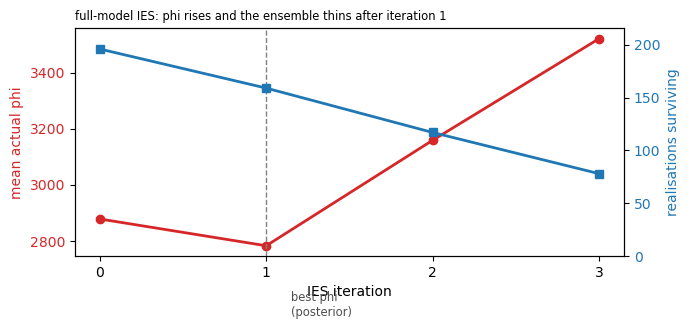

In [5]:
# the convergence picture: phi and survivors, side by side
fig, ax1 = plt.subplots(figsize=(7, 3.5))
its = [0, 1, 2, 3]
ax1.plot(its, mean_phi.loc[its].values, "-o", color="#d62728", lw=2, label="mean actual phi")
ax1.axvline(best_it, color="0.5", ls="--", lw=1)
ax1.annotate("best phi\n(posterior)", xy=(best_it, mean_phi.loc[best_it]),
             xytext=(best_it + 0.15, mean_phi.loc[best_it] - 250),
             fontsize="small", color="0.3")
ax1.set_xlabel("IES iteration")
ax1.set_ylabel("mean actual phi", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")
ax1.set_xticks(its)

ax2 = ax1.twinx()
ax2.plot(its, survivors.loc[its].values, "-s", color="#1f77b4", lw=2,
         label="realisations surviving")
ax2.set_ylabel("realisations surviving", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")
ax2.set_ylim(0, survivors.max() * 1.1)

ax1.set_title("full-model IES: phi rises and the ensemble thins after iteration 1",
              loc="left", fontsize="small")
fig.tight_layout()

Read the two curves together. Phi falls from the prior (iteration 0) to iteration 1 — the data pulled the ensemble toward a better fit, as it should. Then it *rises* through iterations 2 and 3, while the surviving ensemble collapses from 197 realisations to 79. This is not convergence; it is the opposite. The smoother, pushing further against a stiff nonlinear model, is taking damaging steps: realisations destabilise and are discarded, and the survivors fit the data *worse* than at iteration 1. The narrowing ensemble is a warning light, not a tightening posterior — fewer realisations is not more confidence when they were *lost*, not informed.

So the defensible posterior is **iteration 1** — the best mean actual phi, with the fullest surviving ensemble of the post-prior iterations. Taking iteration 3 because "it is last" would carry forward a worse fit on a third of the ensemble. This is a judgment call, and we make it on the evidence: best phi, before divergence. We keep iteration 1 as the full-model posterior, and we will use the prior (iteration 0) as the shared baseline against DSI.

### Pin down the forecast, and load the cheap side

The forecast the whole series is judged on is **peak SO₄ at the supply well (`wellopt`) over the supply period** (days 308–728): the maximum over *all three* supply-well screens (`welopt-ly1`, `welopt-ly3`, `welopt-ly5`) and over all supply-period times, of the SO₄ concentration. SO₄ is carried in **mol/L** in the model output, so we convert each realisation's peak to **mg/L** (molar mass ≈ 96.06 g/mol), the decision-readable convention from [part1_05](../part1_05_dsi_basics/dizon_dsi_basics.ipynb). The payoff is the forecast *distribution* — median and P95 — not an exceedance count.

We define the peak-SO₄ reduction once, then apply it to every ensemble: the full-model prior (iteration 0), the full-model posterior (iteration 1), and the DSI posterior loaded from part1_05. The synthetic truth's peak comes from `hm.pst`'s observation values, which were set to realisation 53's outputs before the run — the cleanest single source, no second file to load.

In [6]:
SO4_MW = 96.06  # g/mol  (mol/L -> mg/L)
FORECAST_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]

# the forecast columns in hm.pst: supply-well SO4 over the supply window, all screens
obs = pst_fom.observation_data.copy()
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")
fore_obs = obs.loc[obs.obsid.isin(FORECAST_SCREENS)
                   & (obs.variable == "so4")
                   & (obs.time >= 308) & (obs.time <= 728)]
fore_cols = fore_obs.obsnme.tolist()
print(f"supply-well SO4 forecast columns (all three screens, day 308-728): "
      f"{len(fore_cols)}")

def peak_so4_mgl(ensemble):
    """Peak supply-period SO4 (mg/L): max over all supply screens and times, per real."""
    cols = [c for c in fore_cols if c in ensemble.columns]
    return ensemble.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW

# the synthetic truth's forecast: hm.pst obsvals were set to realisation 53 before the run
truth_peak = float(obs.set_index("obsnme").loc[fore_cols, "obsval"].astype(float).max()
                   * 1000.0 * SO4_MW)
print(f"synthetic truth (realisation 53) peak SO4: {truth_peak:.1f} mg/L")

supply-well SO4 forecast columns (all three screens, day 308-728): 1263
synthetic truth (realisation 53) peak SO4: 89.2 mg/L


In [7]:
# the DSI posterior from part1_05 (its last iteration). Same forecast definition.
pst_dsi = pyemu.Pst(str(dsi_d / "dsi.pst"))
pst_dsi.try_parse_name_metadata()
last_dsi = max(i for i in [0, 1, 2, 3] if (dsi_d / f"dsi.{i}.obs.jcb").exists())
oe_dsi = pyemu.ObservationEnsemble.from_binary(
    pst=pst_dsi, filename=str(dsi_d / f"dsi.{last_dsi}.obs.jcb"))
oe_dsi = oe_dsi._df if hasattr(oe_dsi, "_df") else pd.DataFrame(oe_dsi)
if "base" in oe_dsi.index:
    oe_dsi = oe_dsi.drop(index="base")

# peak SO4 (mg/L) for each ensemble we will compare
peak_prior = peak_so4_mgl(oe_fom[0])   # full-model prior  (shared baseline)
peak_post = peak_so4_mgl(oe_fom[1])    # full-model posterior (best phi = iter 1)
peak_dsi = peak_so4_mgl(oe_dsi)        # DSI posterior

print(f"full-model prior      : {peak_prior.shape[0]:4d} reals")
print(f"full-model posterior  : {peak_post.shape[0]:4d} reals (iteration 1)")
print(f"DSI posterior         : {peak_dsi.shape[0]:4d} reals (iteration {last_dsi})")
print("\nthe three ensembles are different sizes -- attrition on the full-model side, "
      "abundance on the cheap DSI side. That is fine for comparing distributions.")

full-model prior      :  196 reals
full-model posterior  :  159 reals (iteration 1)
DSI posterior         :  499 reals (iteration 3)

the three ensembles are different sizes -- attrition on the full-model side, abundance on the cheap DSI side. That is fine for comparing distributions.


### The three-way payoff

Here is the comparison the whole notebook is for. We overlay the forecast distribution three ways, with the synthetic truth marked:

- the **full-model prior** (grey) — the shared starting point both posteriors moved away from;
- the **full-model posterior** (orange) — iteration 1, the expensive answer;
- the **DSI posterior** (blue) — the cheap answer we want to trust.

Read it as a distribution: where the median sits, where the P95 sits (the operator designs treatment capacity to the P95), and whether each posterior *covers* the truth. The question is not "do they overlay exactly" — two different conditioning machines on a nonlinear model will not. The question is whether they agree on the *direction and rough magnitude* of what the data did to the forecast, and whether both bracket the truth.

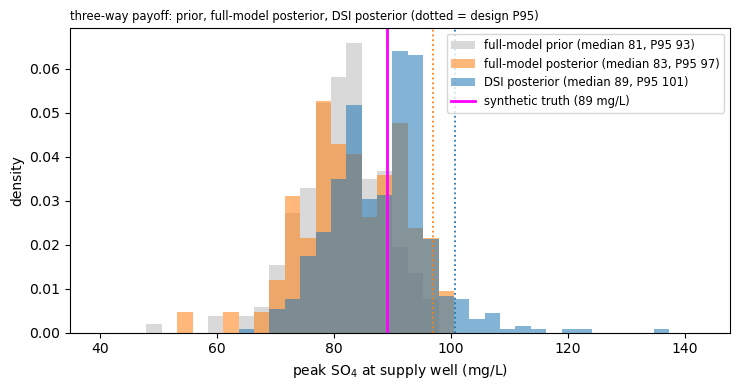

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
fc_max = max(peak_prior.max(), peak_post.max(), peak_dsi.max())
bins = np.linspace(40, fc_max * 1.05, 40)

ax.hist(peak_prior, bins=bins, color="#D3D3D3", alpha=0.85, density=True,
        label=f"full-model prior (median {peak_prior.median():.0f}, "
              f"P95 {peak_prior.quantile(0.95):.0f})")
ax.hist(peak_post, bins=bins, color="#ff7f0e", alpha=0.55, density=True,
        label=f"full-model posterior (median {peak_post.median():.0f}, "
              f"P95 {peak_post.quantile(0.95):.0f})")
ax.hist(peak_dsi, bins=bins, color="#1f77b4", alpha=0.55, density=True,
        label=f"DSI posterior (median {peak_dsi.median():.0f}, "
              f"P95 {peak_dsi.quantile(0.95):.0f})")

# the design P95 each posterior would build treatment capacity to
ax.axvline(peak_post.quantile(0.95), color="#ff7f0e", ls=":", lw=1.3)
ax.axvline(peak_dsi.quantile(0.95), color="#1f77b4", ls=":", lw=1.3)
ax.axvline(truth_peak, color="fuchsia", lw=2,
           label=f"synthetic truth ({truth_peak:.0f} mg/L)")

ax.set_xlabel("peak SO$_4$ at supply well (mg/L)")
ax.set_ylabel("density")
ax.set_title("three-way payoff: prior, full-model posterior, DSI posterior "
             "(dotted = design P95)", loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()

State it as the design numbers a decision-maker carries out of the room: median, the 5–95% band, the design P95, and the contract-trigger risk P(peak > 90 mg/L). We also report the **full-model forecast at every iteration**, so the divergence we diagnosed above is visible in the forecast itself, not just in phi.

In [9]:
def fc_stats(peaks):
    lo, hi = peaks.quantile(0.05), peaks.quantile(0.95)
    return {
        "n reals": int(peaks.shape[0]),
        "median": round(float(peaks.median())),
        "P5": round(float(lo)),
        "P95": round(float(hi)),
        "P(>90)": round(float((peaks > 90).mean()), 2),
        "covers truth": "yes" if lo <= truth_peak <= hi else "no",
    }

summary = pd.DataFrame(
    [fc_stats(peak_prior), fc_stats(peak_post), fc_stats(peak_dsi)],
    index=["full-model prior", "full-model posterior (it1)", "DSI posterior"],
)
print("peak SO4 at supply well (mg/L):")
print(summary.to_string())

# the full-model forecast at every iteration -- the divergence, in the forecast itself
print("\nfull-model forecast by iteration (divergence after iter 1):")
it_tbl = pd.DataFrame(
    {it: fc_stats(peak_so4_mgl(oe_fom[it])) for it in [0, 1, 2, 3]}).T
it_tbl.index.name = "iteration"
it_tbl["mean phi"] = mean_phi.loc[[0, 1, 2, 3]].round(0).astype(int).values
print(it_tbl[["n reals", "mean phi", "median", "P5", "P95", "P(>90)"]].to_string())

peak SO4 at supply well (mg/L):
                            n reals  median  P5  P95  P(>90) covers truth
full-model prior                196      81  70   93    0.11          yes
full-model posterior (it1)      159      83  71   97    0.27          yes
DSI posterior                   499      89  76  101    0.47          yes

full-model forecast by iteration (divergence after iter 1):
          n reals  mean phi median  P5 P95 P(>90)
iteration                                        
0             196      2879     81  70  93   0.11
1             159      2783     83  71  97   0.27
2             117      3159     80  63  95   0.16
3              78      3521     80  63  93   0.17


Read this honestly, because the result is interesting precisely where it is not tidy.

**Both posteriors move the same direction.** The prior median sits near 81 mg/L and under-predicts the truth; *both* conditioning routes lift the forecast up toward it, and *both* 5–95% bands cover the truth. That is the headline: the data carry a real, recoverable signal — peak SO₄ is higher than the prior median guessed — and two independent machines agree on it. The value of data here is truer news, not better news.

**But they do not move the same distance.** The emulator moves *further*: its median lands at 89 mg/L, essentially on the truth, and it puts nearly half its mass above the 90 mg/L trigger (P ≈ 0.47). The full-model posterior is **milder** — its median lifts only to 83, and its exceedance probability to ≈ 0.27. Neither posterior tightens much against the prior (the bands stay roughly as wide, which is itself honest — the history data do not pin this forecast hard). The difference is *where the mass sits*, not how narrow the band is. Where they disagree, the emulator is the **bolder** claim: it commits to a higher forecast with more confidence in exceedance.

So credibility does not come from agreement. The emulator's claim rests on its own audit — the fidelity check and the 6-of-6 coverage in part1_05 — not on matching a full-model run that itself fought to converge. Neither machine is an oracle. What the comparison earns us is a *bound*: both routes agree the forecast is higher than the prior and both cover the truth, so the decision-relevant answer lives in that bracketed range, and the emulator's sharper, higher version of it is defensible on the strength of its calibration.

### What conditioning visibly improved: the fit bundle

The forecast distribution tells us *where* the answer landed; it does not show the data doing its work. For that we look at the **fit bundle** — the SO₄ breakthrough series at the three sites the thinned artifact keeps for both iteration 0 and iteration 1 (`welopt-ly3`, `wp1-f3`, `wp4-f5`). We overlay the full-model prior (iteration 0, grey), the full-model posterior (iteration 1, orange), and the synthetic truth (magenta). The history period ends at the decision date, day 252; everything to the right of it the posterior is extrapolating.

This is the picture of conditioning: where the orange band has pulled in around the magenta line relative to the grey, the data taught the model something. SO₄ is in mol/L here; we leave it in model units, since the question is the *shape* of the fit, not a decision number.

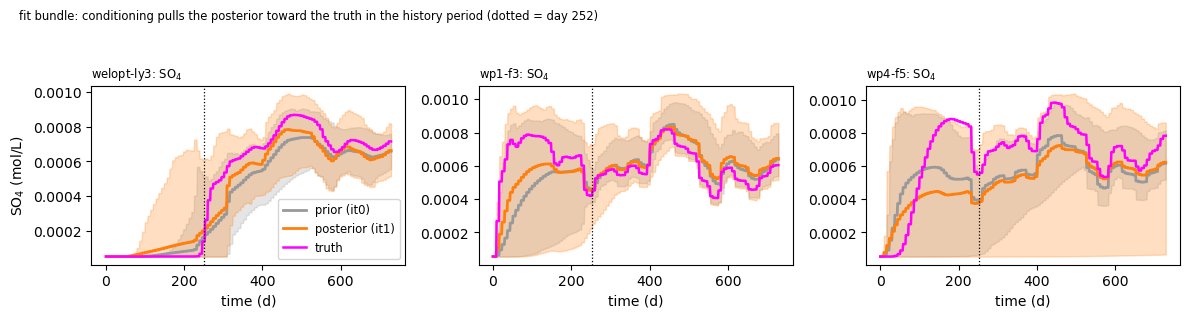

In [10]:
# fit-bundle SO4 series, prior (it0) vs posterior (it1) vs truth, at the three sites
BUNDLE_SITES = ["welopt-ly3", "wp1-f3", "wp4-f5"]
truth_vals = obs.set_index("obsnme")["obsval"].astype(float)

def plot_band(ax, x, ens_df, color, label):
    arr = np.asarray(ens_df)
    ax.fill_between(x, np.percentile(arr, 5, axis=0), np.percentile(arr, 95, axis=0),
                    color=color, alpha=0.25)
    ax.plot(x, arr.mean(axis=0), color=color, lw=2.0, label=label)

fig, axs = plt.subplots(1, len(BUNDLE_SITES),
                        figsize=(4 * len(BUNDLE_SITES), 3.2), sharex=True)
for c, oid in enumerate(BUNDLE_SITES):
    ax = axs[c]
    sub = (obs.loc[(obs.obsid == oid) & (obs.variable == "so4") & (obs.time <= 760)]
           .sort_values("time"))
    # iters 0 and 1 carry the full fit bundle; align every series to one time axis
    cols = [x for x in sub.obsnme if x in oe_fom[0].columns]
    t = sub.set_index("obsnme").loc[cols, "time"].values
    plot_band(ax, t, oe_fom[0].loc[:, cols], "0.6", "prior (it0)")
    plot_band(ax, t, oe_fom[1].loc[:, cols], "#ff7f0e", "posterior (it1)")
    ax.plot(t, truth_vals.loc[cols].values, color="fuchsia", lw=1.8, label="truth")
    ax.axvline(252, color="k", ls=":", lw=0.9)
    ax.set_title(f"{oid}: SO$_4$", loc="left", fontsize="small")
    ax.set_xlabel("time (d)")
    if c == 0:
        ax.set_ylabel("SO$_4$ (mol/L)")
        ax.legend(fontsize="small")
fig.suptitle("fit bundle: conditioning pulls the posterior toward the truth in the "
             "history period (dotted = day 252)", x=0.02, ha="left", fontsize="small")
fig.tight_layout(rect=[0, 0, 1, 0.94])

A few things to read off these panels, and to say out loud:

- **In the history period (day ≤ 252)** the orange band tightens around the truth relative to the grey prior — the data the smoother could see did pull the ensemble toward reality. This is what "conditioning worked" looks like at iteration 1, and it is the visible justification for keeping iteration 1 as the posterior.
- **In the supply period (day > 308)** there is no data, so the posterior is extrapolating; the band there is the model propagating what it learned forward to the forecast. The supply-well site (`welopt-ly3`) is where the forecast lives.
- The improvement is real but **modest** — consistent with the milder forecast shift we saw. The full model did not slam the band shut; it nudged it, which is the honest behaviour of a run that was already straining against nonlinearity by the next iteration.

### The verdict

In the terms a decision-maker cares about:

1. **Do the two posteriors agree on the direction?** Yes. Both lift the forecast up from the prior toward the truth, and both 5–95% bands cover it. The data's message — peak SO₄ is higher than the prior median guessed — survives being run through two independent conditioning machines.
2. **Do they agree on the magnitude?** Only roughly. The emulator commits to a higher median (89 vs 83) and a higher exceedance risk (0.47 vs 0.27); the full model is milder. They disagree on the *strength* of the update, not its sign.
3. **So which do we carry forward?** The emulator — but not because it "won the vote". We carry it because its calibration audit in part1_05 (6 of 6 held-out truths covered) earns its sharper, higher claim, while the full-model run that would dispute it visibly diverged after one iteration. The full model bounds the answer and confirms the direction; it does not overrule a better-audited emulator.

As a risk lens on the same comparison — a supply contract with a 90 mg/L trigger — read P(peak > 90 mg/L) off each ensemble:

In [11]:
TRIGGER = 90.0
risk = pd.Series({
    "full-model prior": (peak_prior > TRIGGER).mean(),
    "full-model posterior (it1)": (peak_post > TRIGGER).mean(),
    "DSI posterior": (peak_dsi > TRIGGER).mean(),
}).round(2)
print(f"P(peak SO4 > {TRIGGER:.0f} mg/L):")
print(risk.to_string())

dir_fom = "rose" if risk["full-model posterior (it1)"] > risk["full-model prior"] else "fell"
dir_dsi = "rose" if risk["DSI posterior"] > risk["full-model prior"] else "fell"
print(f"\nfull-model conditioning: contract risk {dir_fom} "
      f"({risk['full-model prior']:.2f} -> {risk['full-model posterior (it1)']:.2f})")
print(f"DSI conditioning:        contract risk {dir_dsi} "
      f"({risk['full-model prior']:.2f} -> {risk['DSI posterior']:.2f}) "
      "-- the same direction, the bolder magnitude")

P(peak SO4 > 90 mg/L):
full-model prior              0.11
full-model posterior (it1)    0.27
DSI posterior                 0.47

full-model conditioning: contract risk rose (0.11 -> 0.27)
DSI conditioning:        contract risk rose (0.11 -> 0.47) -- the same direction, the bolder magnitude


### What it cost, with receipts

This is the spine of the series, stated one last time with the numbers behind it. The full-model history match was **one overnight parallel run** — 200 realisations over 4 IES iterations at ~7 min per forward run, ~12 h on 12 workers — and it diverged after the first update iteration. It bought a single, milder posterior for a single forecast question. The DSI conditioning in part1_05 produced a sharper, calibrated posterior for the *same* question in **minutes**, on top of the prior Monte Carlo we had already paid for.

We spent the overnight run **once**, here, to validate the emulator: both routes agree on the direction of the forecast update and both cover the truth, and the emulator's sharper answer is backed by a coverage audit the full model could never afford to run. That is the receipt. From here on — dataworth, optimization — every new question is answered against the emulator, in seconds, because this one comparison earned us the right to trust it.

In [12]:
# the receipts, side by side
MIN_PER_RUN = 7
total_runs = int(phi["total_runs"].sum())   # forward runs across all IES iterations
serial_h = total_runs * MIN_PER_RUN / 60
print(f"full-model history match: {total_runs} forward runs x ~{MIN_PER_RUN} min "
      f"= ~{serial_h:.0f} h serial, ~12 h on 12 workers (one overnight run)")
print("DSI conditioning (part1_05): minutes against the emulator, "
      "on top of the prior MC we had already paid for")
print(f"\nvalidated once -> reused for free in part1_07 (dataworth) and part1_08 "
      "(optimization)")

full-model history match: 2167 forward runs x ~7 min = ~253 h serial, ~12 h on 12 workers (one overnight run)
DSI conditioning (part1_05): minutes against the emulator, on top of the prior MC we had already paid for

validated once -> reused for free in part1_07 (dataworth) and part1_08 (optimization)


Next: ["Dataworth"](../part1_07_dataworth/dizon_dataworth.ipynb) — the held-back cations cash in. We retrain the emulator on different observation subsets and watch what each does to the forecast, for nearly nothing, because the prior runs already exist.
